# Wireshark Lab: HTTP 

Supplement to Computer Networking: A Top-Down Approach, 9th ed., J.F. Kurose and K.W. Ross

"Tell me and I forget. Show me and I remember. Involve me and I understand." — Chinese proverb

© 2005-2025, J.F. Kurose and K.W. Ross, All Rights Reserved


_______________________________

## Lab overview & objectives



Use Wireshark (or provided traces) to investigate HTTP: basic GET/response, message formats, conditional GETs, embedded objects, authentication, and multi-packet responses.  This notebook organizes the lab steps and questions for easy answering and analysis.

### Before you start (prereqs / notes)


- Make sure you are not running a VPN (virtual private network) service.  
- Make sure your browser program is not, by default, using the HTTP/3 protocol or the QUIC protocol. As of 2025, most popular browsers have adopted HTTP/3 and QUIC as defaults. A document that describes how to disable HTTP/3 AND QUIC as the defaults for your browser is here: https://techysnoop.com/disable-quic-protocol-in-chrome-edge-firefox/ .
- Make sure when you go to a URL, that the URL starts with “http://” rather than with https:// as the latter case will encrypt frames.
- Make sure privacy and browser privacy settings are turned off.
- If you are not running Wireshark on a VM, make sure you clear your browser cache and browser history before you start (not recommended). 


________________________

## 1. The Basic HTTP GET/response interaction — steps

Let’s begin our exploration of HTTP by downloading a very simple HTML file - one that is very short, and contains no embedded objects.  Do the following:

1.	Start up your web browser.
2.	Start up the Wireshark packet sniffer, as described in the Introductory lab (but don’t yet begin packet capture).  Enter “http” (just the letters, not the quotation marks, and in lower case) in the display-filter-specification window, so that only captured HTTP messages will be displayed later in the packet-listing window.  
3.	Wait a bit more than one minute (we’ll see why shortly), and then begin Wireshark packet capture.
4.	Enter the following to your browser
http://gaia.cs.umass.edu/wireshark-labs/HTTP-wireshark-file1.html
Your browser should display the very simple, one-line HTML file.
5.	Stop Wireshark packet capture.

Your Wireshark window should look similar to the window shown in Figure 1. 

Note: Ignore requests/responses for `favicon.ico` (browser auto-request).


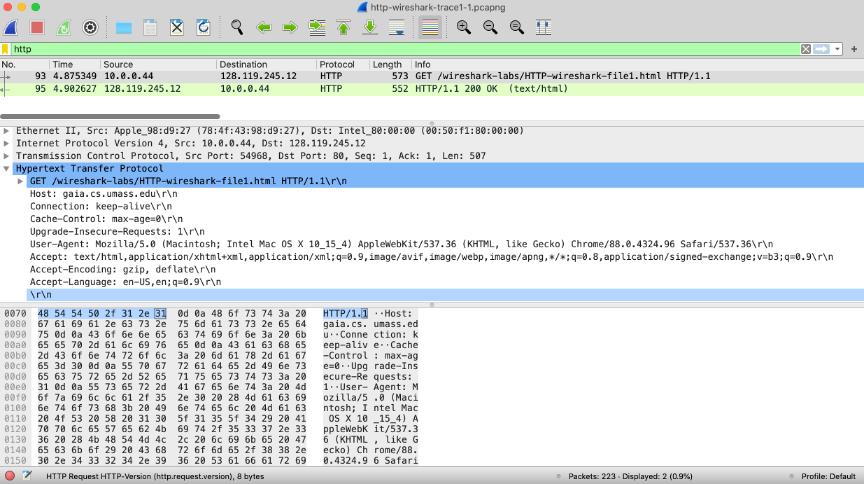 
Figure 1: Wireshark Display after http://gaia.cs.umass.edu/wireshark-labs/ HTTP-wireshark-file1.html has been retrieved by your browser


### Using Trace Files 

 Alternatively, if you’re unable to run Wireshark on a live network connection, you can download a packet trace that was created when the steps above were followed. 


You can download the zip file http://gaia.cs.umass.edu/wireshark-labs/wireshark-traces-9e.zip and extract the trace file http-wireshark-trace1-1. These trace files can be used to answer these Wireshark lab questions without actually capturing packets on your own.  Each trace was made using Wireshark running on one of the author’s computers, while performing the steps indicated in the Wireshark lab. Once you’ve downloaded a trace file, you can load it into Wireshark and view the trace using the File pull down menu, choosing Open, and then selecting the trace file name.  The resulting display should look similar to Figure 1 (for the http-wireshark-trace1-1 trace file for this HTTP lab). The Wireshark user interface displays just a bit differently on different operating systems, and in different versions of Wireshark.

### Infer the following. (part 1)
By looking at the information in the HTTP GET and response messages, answer the following questions.  
1.	Is your browser running HTTP version 1.0, 1.1, or 2?  What version of HTTP is the server running?
2.	What languages (if any) does your browser indicate that it can accept to the server?
3.	What is the IP address of your computer?  What is the IP address of the gaia.cs.umass.edu server?
4.	What is the status code returned from the server to your browser?
5.	When was the HTML file that you are retrieving last modified at the server?
6.	How many bytes of content are being returned to your browser?

In your answer to question 5 above (assuming you’re running Wireshark “live”, as opposed to using an earlier-recorded trace file), you might have been surprised to find that the document you just retrieved was last modified within a minute before you downloaded the document. That’s because (for this particular file), the gaia.cs.umass.edu server is setting the file’s last-modified time to be the current time, and is doing so once per minute. Thus, if you wait a minute between accesses, the file will appear to have been recently modified, and hence your browser will download a “new” copy of the document.

__________________________________



1. Both use 1.1
2. en-US
3. My computer: 192.168.1.5, umass: 128.119.245.12
4. 200
5. Last-Modified: Tue, 28 Oct 2025 05:59:01 GMT (ran live)
6. The Content-Length is 128

## 2. The HTTP CONDITIONAL GET/response interaction — steps

- Clear browser cache.
- Start Wireshark.
- In browser open:
`http://gaia.cs.umass.edu/wireshark-labs/HTTP-wireshark-file2.html`
- Quickly open the same URL again (or refresh).
- Stop capture, set display filter to `http`.

**If you’re unable to run Wireshark on a live network connection, you can download the zip file http://gaia.cs.umass.edu/wireshark-labs/wireshark-traces-9e.zip and extract the trace file http-wireshark-trace2-1.**


### Infer the following. (part 2)

7. Inspect the first HTTP GET: do you see an `If-Modified-Since` header?
8. Inspect the server response: did the server explicitly return the contents of the file? How can you tell?
9. Inspect the second HTTP GET: do you see an `If-Modified-Since:` line? If so, what follows it?
10. What is the HTTP status code and phrase returned by the server for the second GET? Did the server return the file contents? Explain.

__________________________

7. No
8. Yes, I see it in the "Line-based text data: text/html (10 lines)" section.
9. If-Modified-Since: Tue, 28 Oct 2025 05:59:01 GMT\r\n
10. 364 Not Modified was returned. The server did not return file contents, because my browser sent headers indicating that it already had the file, and to only return a new file if changes had been made. Changes have not been made, so the server did not return a file, and specified this in the status code.

## 3. HTML Documents with Embedded Objects — steps

- Clear browser cache.
- Start Wireshark.
- Open:
`http://gaia.cs.umass.edu/wireshark-labs/HTTP-wireshark-file4.html`
- The page should display two images referenced in the base HTML; one hosted on gaia.cs.umass.edu, one hosted on a server in France.
- Stop capture and set the display filter to `http`.


**If you’re unable to run Wireshark on a live network connection, you can download the zip file http://gaia.cs.umass.edu/wireshark-labs/wireshark-traces-9e.zip and extract the trace file http-wireshark-trace4-1.**

### Infer the following. (part 3)

11. How many HTTP GET request messages did your browser send? To which IP addresses were these GETs sent?
12. Did the browser download the images serially or in parallel? Explain using timestamps and connection info.

___________________________________




11. 3: 128.119.245.12 for the HTML file, 128.119.245.12 again for the pearson.png file, and 2a03:4000:3e:5ca:3813:f3ff:fe33:915d for the 8E_cover_small.jpg file
12. They were downloaded in parallel. We see that the connection header in both requests is "keep-alive", and also we see that the second request is sent before the first has finished. This is easier to visualize by using the network tab in browser, where we can more easily see the overlap in requests/responses

## 4. HTTP Authentication — steps

- Clear browser cache and restart browser.
- Start Wireshark.
- Open:
`http://gaia.cs.umass.edu/wireshark-labs/protected_pages/HTTP-wireshark-file5.html`
- When prompted, enter username `wireshark-students` and password `network`.
- Stop capture and filter by `http`.

**If you’re unable to run Wireshark on a live network connection, you can download the zip file http://gaia.cs.umass.edu/wireshark-labs/wireshark-traces-9e.zip and extract the trace file http-wireshark-trace5-1.**

### Infer the following. (part 4)

13. What is the server's response (status code and phrase) to the initial HTTP GET?
14. In the client's second GET, what new field is included?

Note: The `Authorization: Basic <base64>` header encodes `username:password` in Base64 (not encryption). Example string from the lab:
`d2lyZXNoYXJrLXN0dWRlbnRzOm5ldHdvcms=` — split into username and password parts to decode.
You can decode with a Base64 tool or with Python (see helper code cell below).

________________________________

13. 401 Unauthorized
14. Authorization, which contains the Base64 version of wireshark-students:network

## Earn Participation Point 

To earn participation points for this assignment, complete the following task.

**Goal**: Include either your name or your 811 number as part of the observed HTML traffic.

**Approach**: Modify one of the four listed labs as needed so that the chosen webpage (or an embedded resource requested by that page) contains your name or 811 number. The traffic must still be directly related to one of the lab webpages.

You may earn multiple participation points for each distinct method you can demonstrate that results in your name or 811 number appearing in the observed HTML traffic. Show different methods to obtain additional points.

**Deliverable**: Add screenshot(s) to this notebook capturing the observed HTML traffic that includes your name or 811 number along with brief description of the steps you followed to produce that traffic.

Submit the file on eLC. 

---------------------


Note: You can also use the file to keep record of the answers to other questions and add any additional daat (screenshots or executions steps) for your own reference.

## 1
![First Approach](User-Agent%20approach.png)

This approach uses `curl -A "Jesse Franks" http://gaia.cs.umass.edu/wireshark-labs/HTTP-wireshark-file1.html -v` to pass my name as a replacement for the User-Agent header.


## 2

![Second Approach](Search%20Query%20approach.png)

This approach involves using a search bar that doesnt exist on the page, therefore returning a 404.

## 3
![Third Approach](Referer%20approach.png)

This approach uses `curl -e "Jesse Franks" http://gaia.cs.umass.edu/wireshark-labs/HTTP-wireshark-file1.html -v` to pass my name as a referer header.
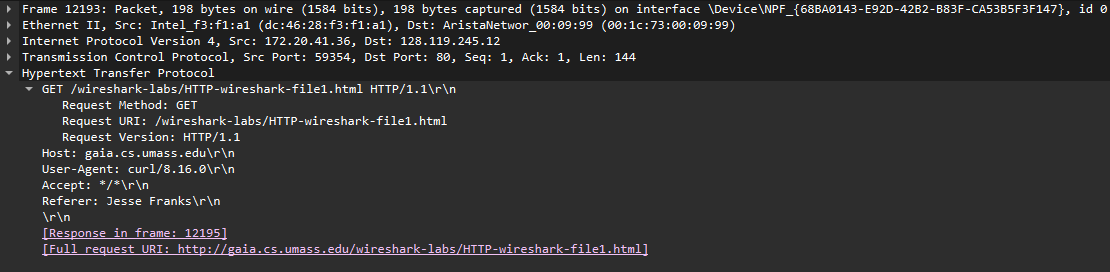